<a href="https://colab.research.google.com/github/Moulis980/Traffic-congestion-reduction/blob/main/Traffic_congestion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml

--2026-03-15 13:36:40--  https://raw.githubusercontent.com/andrewssobral/vehicle_detection_haarcascades/master/cars.xml
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 118803 (116K) [text/plain]
Saving to: ‘cars.xml’

cars.xml            100%[===================>] 116.02K  --.-KB/s    in 0.02s   

2026-03-15 13:36:40 (5.28 MB/s) - ‘cars.xml’ saved [118803/118803]



In [ ]:
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

SPEED_LIMIT = 60  # km/h
PIXELS_TO_METERS = 20  # Adjust this based on your video scale!
FIXED_FINE_AMOUNT = 200  # Fixed fine for any overspeeding

vehicle_detector = cv2.CascadeClassifier('cars.xml')

lanes = [
    [(335,494), (425,494), (260,1000), (-200, 1000)],
    [(425,494), (515,494), (520,1000), (260,1000)],
    [(515,494), (605,494), (810,1000), (520,1000)],
    [(605,494), (695,494), (1200,1000), (810,1000)]
]

vehicle_tracker = {}
vehicle_speeds = {}

def detect_vehicles(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    vehicles = vehicle_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    return vehicles

def is_point_in_lane(x, y, polygon):
    pts = np.array(polygon, np.int32)
    return cv2.pointPolygonTest(pts, (int(x), int(y)), False) >= 0

def calculate_speed(vehicle_id, current_position):
    if vehicle_id in vehicle_tracker:
        previous_position, previous_time = vehicle_tracker[vehicle_id]
        distance = np.linalg.norm(np.array(current_position) - np.array(previous_position)) * PIXELS_TO_METERS
        time_elapsed = time.time() - previous_time
        if time_elapsed > 0:
            speed = (distance / time_elapsed) * 3.6  # m/s to km/h
            vehicle_speeds[vehicle_id] = speed
    vehicle_tracker[vehicle_id] = (current_position, time.time())

def draw_lanes(frame):
    for i, lane in enumerate(lanes):
        pts = np.array(lane, np.int32)
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)
        cv2.putText(frame, f"Lane {i + 1}", (lane[0][0] + 10, lane[0][1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

def main(video_path):
    cap = cv2.VideoCapture(video_path)
    frame_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        vehicles = detect_vehicles(frame)
        lane_counts = [0] * len(lanes)

        for (x, y, w, h) in vehicles:
            center_x = x + w // 2
            center_y = y + h // 2
            vehicle_id = f"{x}_{y}"

            for i, lane in enumerate(lanes):
                if is_point_in_lane(center_x, center_y, lane):
                    lane_counts[i] += 1
                    break

            calculate_speed(vehicle_id, (center_x, center_y))

            speed = vehicle_speeds.get(vehicle_id, 0)
            color = (0, 255, 0) if speed <= SPEED_LIMIT else (0, 0, 255)
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

        draw_lanes(frame)

        if frame_count % 10 == 0:
            summary = " | ".join([f"Lane {i+1}: {count} vehicles" for i, count in enumerate(lane_counts)])
            print(f"\nFrame {frame_count}: {summary}")

            for vid, spd in vehicle_speeds.items():
                if spd > SPEED_LIMIT:
                    print(f"Vehicle {vid}: {spd:.2f} km/h ⚠️ OVERSPEED | Fine: ${FIXED_FINE_AMOUNT}")
                else:
                    print(f"Vehicle {vid}: {spd:.2f} km/h")

            cv2_imshow(frame)

        frame_count += 1

    cap.release()

# ==== Run ====
video_path = "/content/videoplayback.mp4"
main(video_path)


Frame 0: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 0 vehicles


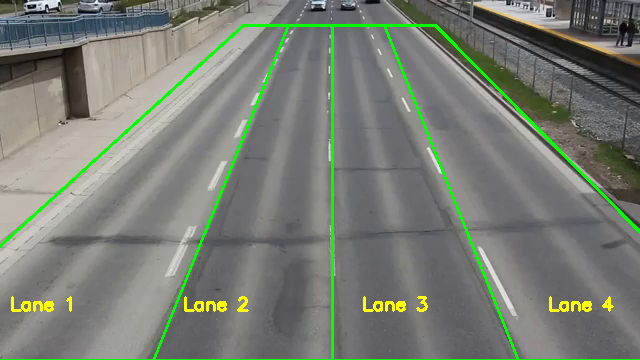


Frame 10: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 0 vehicles


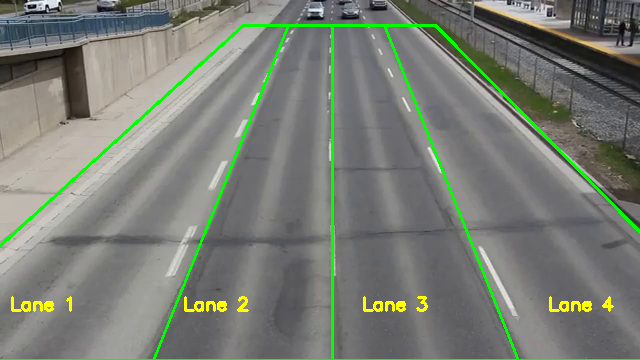


Frame 20: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 0 vehicles


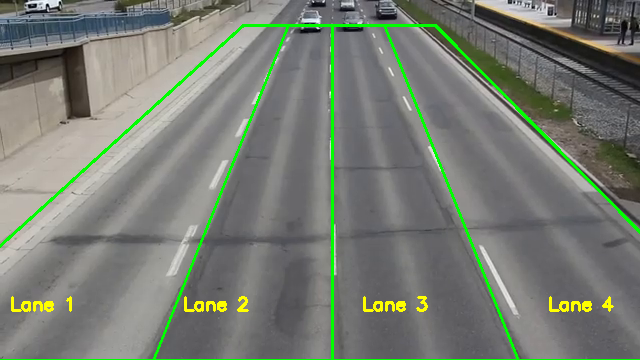


Frame 30: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200


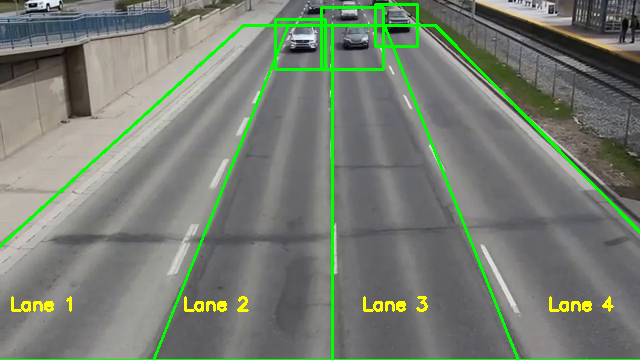


Frame 40: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200


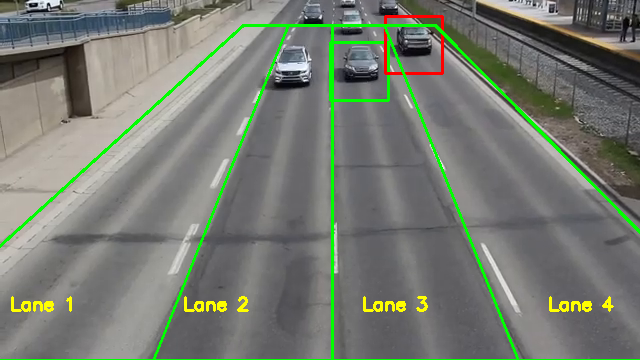


Frame 50: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200


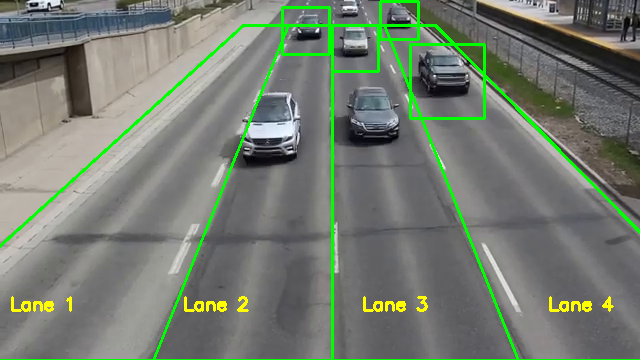


Frame 60: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200


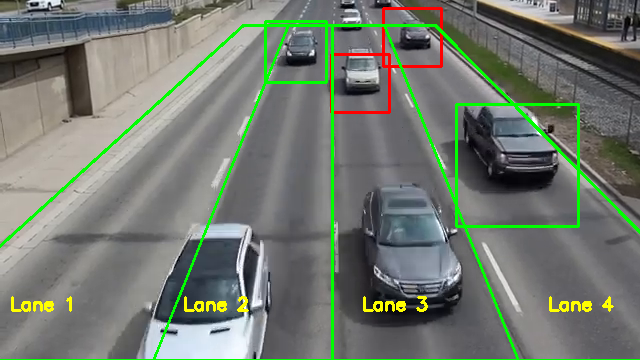


Frame 70: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 2 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200


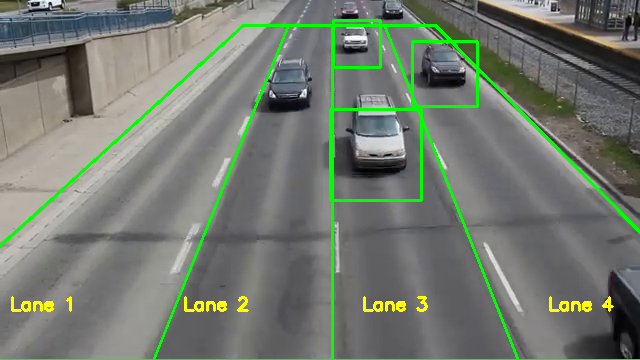


Frame 80: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200


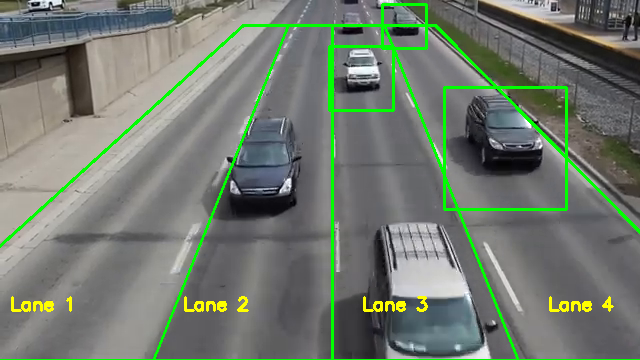


Frame 90: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h


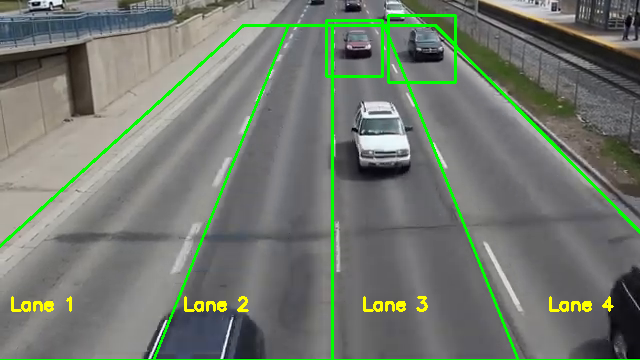


Frame 100: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200


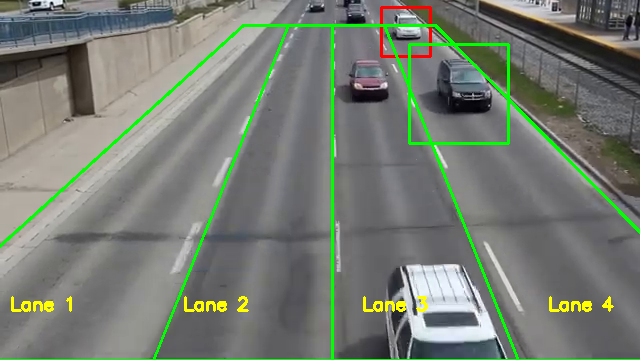


Frame 110: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200


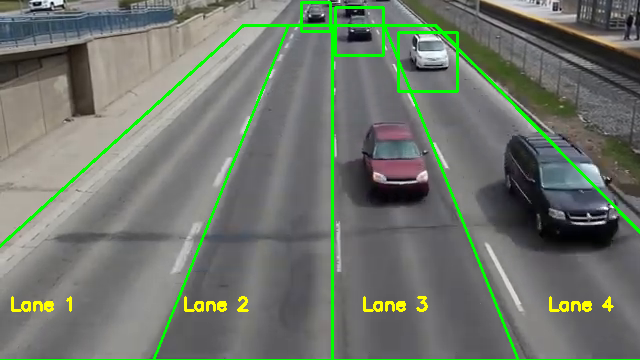


Frame 120: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 0 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200


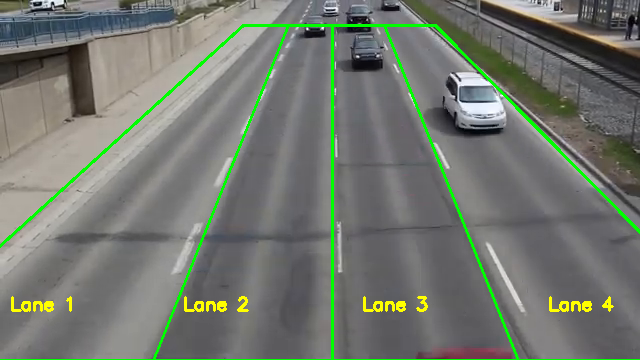


Frame 130: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 0 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200


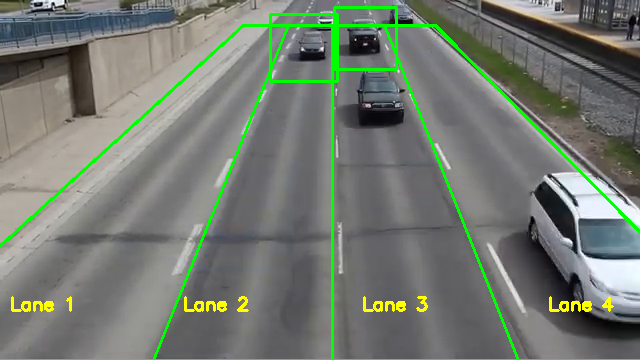


Frame 140: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

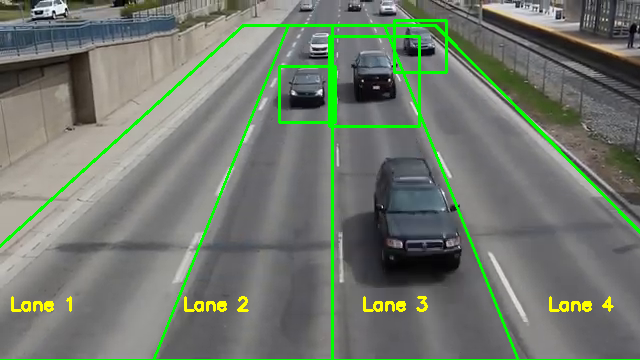


Frame 150: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

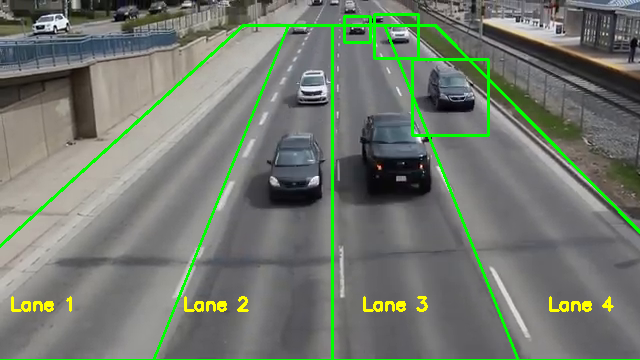


Frame 160: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

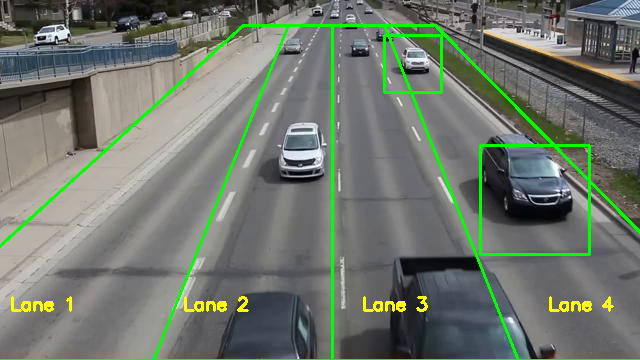


Frame 170: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

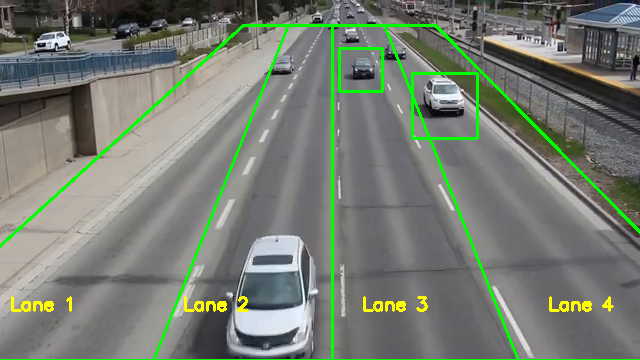


Frame 180: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 2 vehicles | Lane 4: 2 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

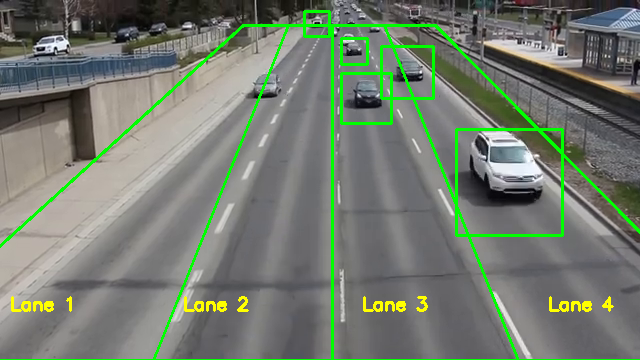


Frame 190: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 2 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

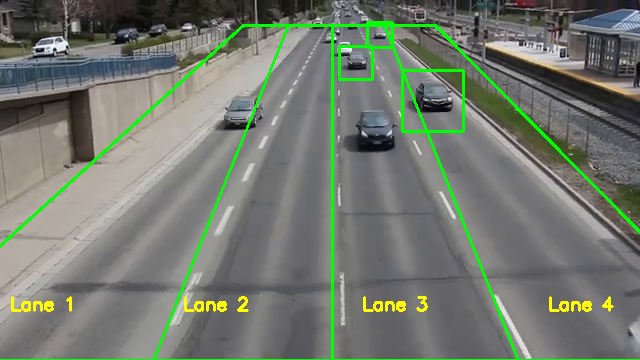


Frame 200: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 2 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

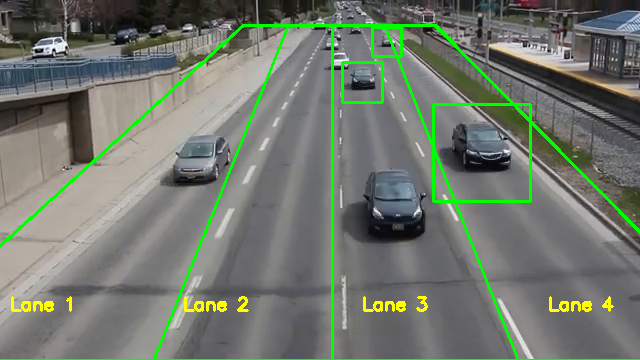


Frame 210: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 2 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

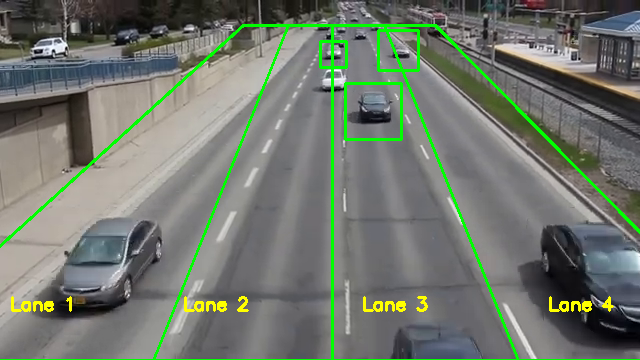


Frame 220: Lane 1: 0 vehicles | Lane 2: 2 vehicles | Lane 3: 0 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

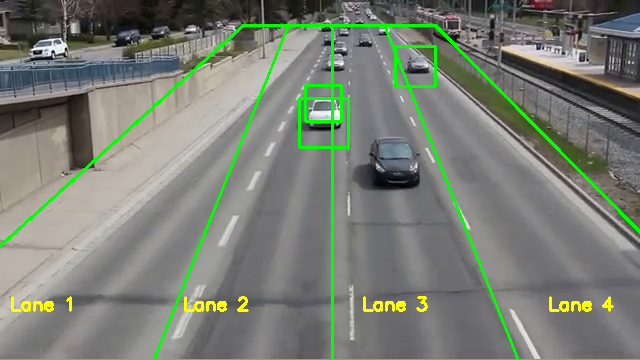


Frame 230: Lane 1: 1 vehicles | Lane 2: 2 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

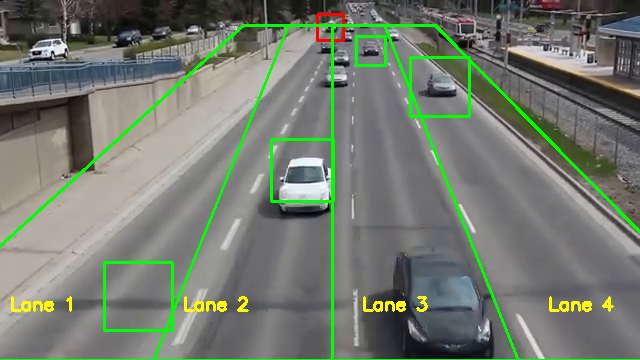


Frame 240: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

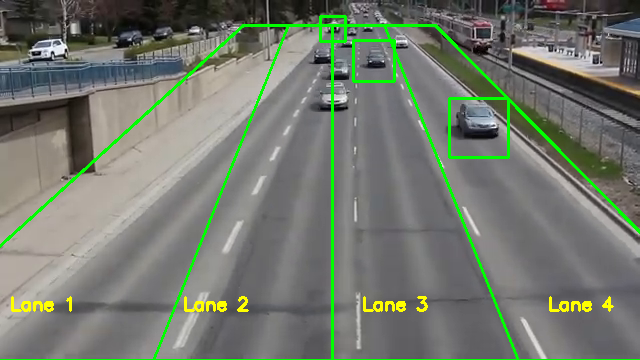


Frame 250: Lane 1: 0 vehicles | Lane 2: 2 vehicles | Lane 3: 3 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

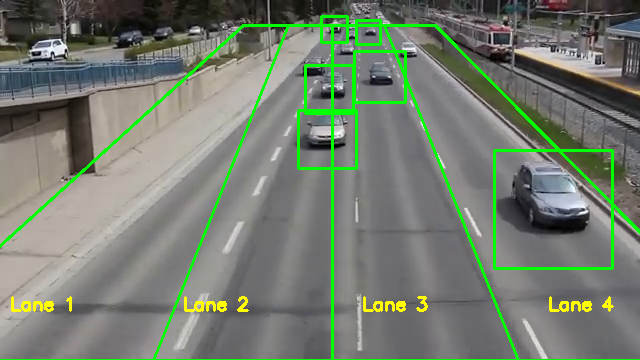


Frame 260: Lane 1: 0 vehicles | Lane 2: 2 vehicles | Lane 3: 3 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

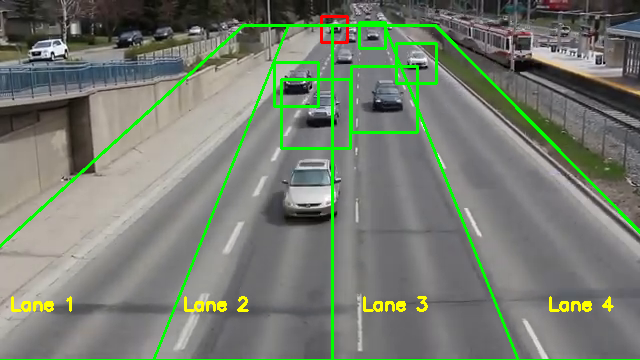


Frame 270: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 3 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

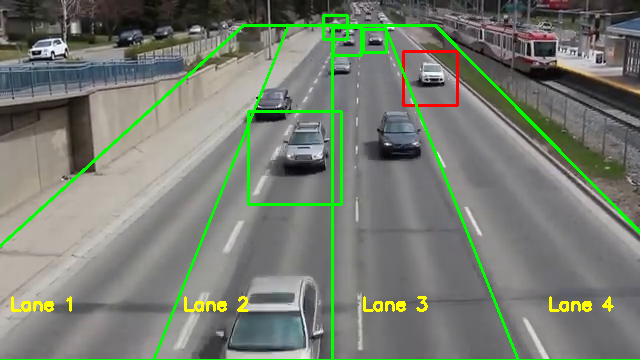


Frame 280: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

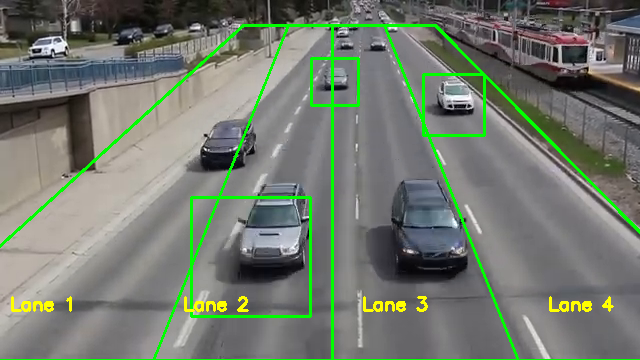


Frame 290: Lane 1: 0 vehicles | Lane 2: 0 vehicles | Lane 3: 0 vehicles | Lane 4: 1 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

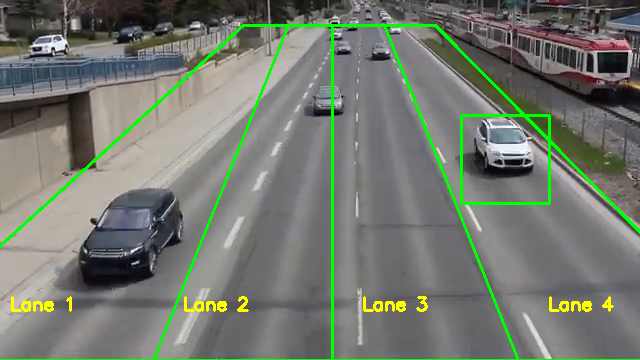


Frame 300: Lane 1: 0 vehicles | Lane 2: 1 vehicles | Lane 3: 1 vehicles | Lane 4: 0 vehicles
Vehicle 330_5: 5023.39 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 379_8: 4911.09 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 385_16: 4730.18 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 378_2: 2217.83 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 331_54: 225.26 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 383_8: 3127.69 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 390_18: 3603.66 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 321_7: 288.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 382_4: 1877.16 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 329_11: 0.00 km/h
Vehicle 401_28: 131.77 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 376_4: 27.39 km/h
Vehicle 381_10: 140.72 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 381_7: 3491.49 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 387_14: 256.29 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 338_3: 2530.07 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 337_4: 98.43 km/h ⚠️ OVERSPEED | Fine: $200
Vehicle 389_10: 2285.92 km/h ⚠️ OVERSPEED | F

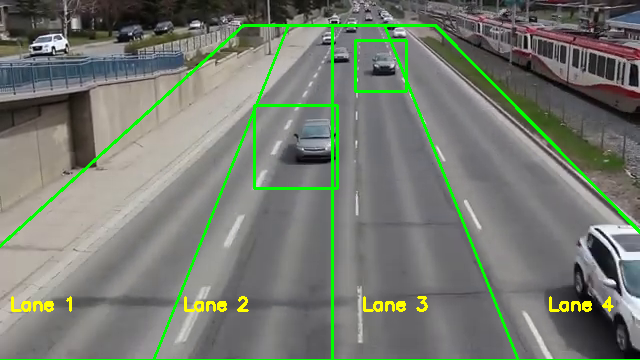

In [ ]:
import cv2
import numpy as np
import time
from google.colab.patches import cv2_imshow

SPEED_LIMIT = 60  # km/h
PIXELS_TO_METERS = 20  # Adjust this based on your video scale!
FIXED_FINE_AMOUNT = 200  # Fixed fine for any overspeeding

vehicle_detector = cv2.CascadeClassifier('cars.xml')

RELATIVE_LANES = [
    [(0.38, 0.07), (0.45, 0.07), (0.24, 1.0), (-0.20, 1.0)], # Lane 1
    [(0.45, 0.07), (0.52, 0.07), (0.52, 1.0), (0.24, 1.0)],  # Lane 2
    [(0.52, 0.07), (0.6, 0.07), (0.81, 1.0), (0.52, 1.0)],  # Lane 3
    [(0.6, 0.07), (0.68, 0.07), (1.20, 1.0), (0.81, 1.0)]   # Lane 4
]

lanes = [] # This will be populated dynamically in main()

vehicle_tracker = {}
vehicle_speeds = {}

def detect_vehicles(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    vehicles = vehicle_detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)
    return vehicles

def is_point_in_lane(x, y, polygon):
    pts = np.array(polygon, np.int32)
    return cv2.pointPolygonTest(pts, (int(x), int(y)), False) >= 0

def calculate_speed(vehicle_id, current_position):
    if vehicle_id in vehicle_tracker:
        previous_position, previous_time = vehicle_tracker[vehicle_id]
        distance = np.linalg.norm(np.array(current_position) - np.array(previous_position)) * PIXELS_TO_METERS
        time_elapsed = time.time() - previous_time
        if time_elapsed > 0:
            speed = (distance / time_elapsed) * 3.6  # m/s to km/h
            vehicle_speeds[vehicle_id] = speed
    vehicle_tracker[vehicle_id] = (current_position, time.time())

def draw_lanes(frame):
    for i, lane in enumerate(lanes):
        pts = np.array(lane, np.int32)
        cv2.polylines(frame, [pts], isClosed=True, color=(0, 255, 0), thickness=2)

        # Move the text to the bottom of the screen where lanes are wider
        # Using max(10, ...) ensures the text doesn't go off-screen on the left
        text_x = max(10, lane[3][0] + 30)
        text_y = lane[3][1] - 50
        cv2.putText(frame, f"Lane {i + 1}", (text_x, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2)

def main(video_path):
    global lanes
    cap = cv2.VideoCapture(video_path)
    frame_count = 0

    # Read the first frame to get the exact video dimensions
    ret, frame = cap.read()
    if not ret:
        print("Failed to read video. Please check the path.")
        return

    height, width = frame.shape[:2]

    # Convert relative percentages into exact pixel coordinates for your specific video
    lanes = []
    for lane in RELATIVE_LANES:
        absolute_lane = [(int(x * width), int(y * height)) for x, y in lane]
        lanes.append(absolute_lane)

    # Reset the video back to the first frame so we don't skip it
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        vehicles = detect_vehicles(frame)
        lane_counts = [0] * len(lanes)

        for (x, y, w, h) in vehicles:
            center_x = x + w // 2
            center_y = y + h // 2

            # Note: This tracking ID approach will still cause speed resets on every frame
            vehicle_id = f"{x}_{y}"

            for i, lane in enumerate(lanes):
                if is_point_in_lane(center_x, center_y, lane):
                    lane_counts[i] += 1
                    break

            calculate_speed(vehicle_id, (center_x, center_y))

            speed = vehicle_speeds.get(vehicle_id, 0)
            color = (0, 255, 0) if speed <= SPEED_LIMIT else (0, 0, 255)
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)

        draw_lanes(frame)

        if frame_count % 10 == 0:
            summary = " | ".join([f"Lane {i+1}: {count} vehicles" for i, count in enumerate(lane_counts)])
            print(f"\nFrame {frame_count}: {summary}")

            for vid, spd in vehicle_speeds.items():
                if spd > SPEED_LIMIT:
                    print(f"Vehicle {vid}: {spd:.2f} km/h ⚠️ OVERSPEED | Fine: ${FIXED_FINE_AMOUNT}")
                else:
                    print(f"Vehicle {vid}: {spd:.2f} km/h")

            cv2_imshow(frame)

        frame_count += 1

    cap.release()

# ==== Run ====
video_path = "/content/videoplayback.mp4"
main(video_path)